In [ ]:
# analyze exoplanet data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
df = pd.read_csv('exoplanet_data.csv', comment='#')

In [14]:
df.shape
# 567 rows, 92 columns

(567, 92)

In [15]:
df.columns.tolist()
# sy_snum, sy_pnum, pl_bmasseerr1, pl_eqt, sy_vmagerr1

['pl_name',
 'hostname',
 'default_flag',
 'sy_snum',
 'sy_pnum',
 'discoverymethod',
 'disc_year',
 'disc_facility',
 'soltype',
 'pl_controv_flag',
 'pl_refname',
 'pl_orbper',
 'pl_orbpererr1',
 'pl_orbpererr2',
 'pl_orbperlim',
 'pl_orbsmax',
 'pl_orbsmaxerr1',
 'pl_orbsmaxerr2',
 'pl_orbsmaxlim',
 'pl_rade',
 'pl_radeerr1',
 'pl_radeerr2',
 'pl_radelim',
 'pl_radj',
 'pl_radjerr1',
 'pl_radjerr2',
 'pl_radjlim',
 'pl_bmasse',
 'pl_bmasseerr1',
 'pl_bmasseerr2',
 'pl_bmasselim',
 'pl_bmassj',
 'pl_bmassjerr1',
 'pl_bmassjerr2',
 'pl_bmassjlim',
 'pl_bmassprov',
 'pl_orbeccen',
 'pl_orbeccenerr1',
 'pl_orbeccenerr2',
 'pl_orbeccenlim',
 'pl_insol',
 'pl_insolerr1',
 'pl_insolerr2',
 'pl_insollim',
 'pl_eqt',
 'pl_eqterr1',
 'pl_eqterr2',
 'pl_eqtlim',
 'ttv_flag',
 'st_refname',
 'st_spectype',
 'st_teff',
 'st_tefferr1',
 'st_tefferr2',
 'st_tefflim',
 'st_rad',
 'st_raderr1',
 'st_raderr2',
 'st_radlim',
 'st_mass',
 'st_masserr1',
 'st_masserr2',
 'st_masslim',
 'st_met',
 'st_me

In [28]:
columns_to_keep = [
    'pl_name', # Planet Name
    'hostname',  # Star Name
    'discoverymethod',  # Discovery Method
    'st_spectype',  # Stellar Type
    'pl_eqt',  # Equillibrium Temperature
    'pl_bmassj'  # Planet Mass (in jupiter masses)
]

df_small = df[columns_to_keep]

In [17]:
df_filtered = df_small.dropna()

In [19]:
df_filtered.shape
# 67 rows, 6 columns

(67, 6)

In [21]:
df_filtered.head()

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
2,DMPP-1 b,DMPP-1,Radial Velocity,F8 V,877.0,0.076362
3,DMPP-1 c,DMPP-1,Radial Velocity,F8 V,1239.0,0.030205
4,DMPP-1 d,DMPP-1,Radial Velocity,F8 V,1632.0,0.010540
5,DMPP-1 e,DMPP-1,Radial Velocity,F8 V,1314.0,0.012994
6,DMPP-2 b,DMPP-2,Radial Velocity,F5 V,1000.0,0.437000


In [23]:
df_filtered.tail()

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
546,WASP-185 b,WASP-185,Transit,G0 V,1160.0,0.980
549,WASP-190 b,WASP-190,Transit,F6 IV-V,1500.0,1.000
555,WASP-192 b,WASP-192,Transit,G0 V,1620.0,2.300
561,XO-7 b,XO-7,Transit,G0 V,1743.0,0.709
566,eps Ind A b,eps Ind A,Radial Velocity,K5 V,275.0,6.310


In [26]:
method_counts = df_filtered['discoverymethod'].value_counts()
print(method_counts)
# Transit: most; uses telescopes watching stars to see if their light dims as a planet passes infront of it
# Radial Velocity: uses doppler shits in the planets light to determine the presence of an orbiting planet
# Imaging: least; uses telescopes to image stars and find planets within the image

discoverymethod
Transit            52
Radial Velocity    13
Imaging             2
Name: count, dtype: int64


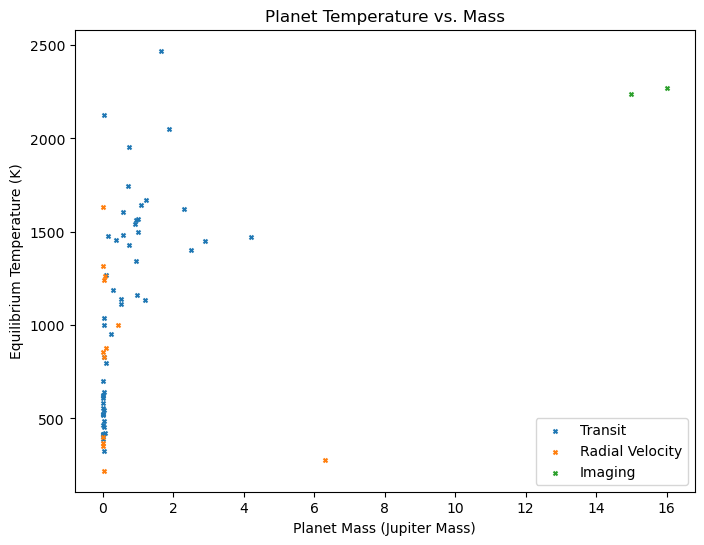

In [42]:
mass_col = 'pl_bmassj'
temp_col = 'pl_eqt'
discover_col = 'discoverymethod'

plt.figure(figsize=(8, 6))

df_transit = df_filtered[df_filtered[discover_col] == 'Transit'] 
plt.scatter(df_transit[mass_col], df_transit[temp_col], label='Transit', s=8, marker='x')

df_rv = df_filtered[df_filtered[discover_col] == 'Radial Velocity']
plt.scatter(df_rv[mass_col], df_rv[temp_col], label='Radial Velocity', s=8, marker='x')

df_imaging = df_filtered[df_filtered[discover_col] == 'Imaging']
plt.scatter(df_imaging[mass_col], df_imaging[temp_col], label='Imaging', s=8, marker='x')

plt.title('Planet Temperature vs. Mass')
plt.xlabel('Planet Mass (Jupiter Mass)')
plt.ylabel('Equilibrium Temperature (K)')
plt.legend()

plt.show()

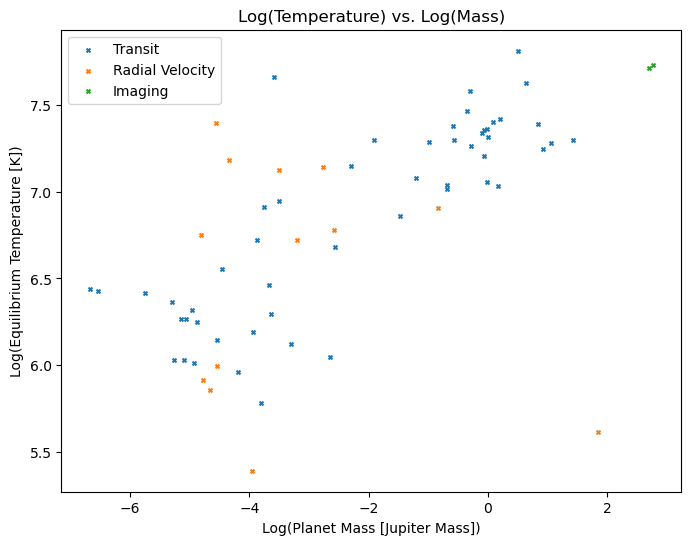

In [44]:
plt.figure(figsize=(8, 6))

df_transit = df_filtered[df_filtered[discover_col] == 'Transit'] 
plt.scatter(np.log(df_transit[mass_col]), np.log(df_transit[temp_col]), label='Transit', s=8, marker='x')

df_rv = df_filtered[df_filtered[discover_col] == 'Radial Velocity']
plt.scatter(np.log(df_rv[mass_col]), np.log(df_rv[temp_col]), label='Radial Velocity', s=8, marker='x')

df_imaging = df_filtered[df_filtered[discover_col] == 'Imaging']
plt.scatter(np.log(df_imaging[mass_col]), np.log(df_imaging[temp_col]), label='Imaging', s=8, marker='x')

plt.title('Log(Temperature) vs. Log(Mass)')
plt.xlabel('Log(Planet Mass [Jupiter Mass])')
plt.ylabel('Log(Equilibrium Temperature [K])')
plt.legend()

plt.show()

In [ ]:
# Imaging seems to work only with very massive planets, which makes sense as they otherwise wouldn't show up in images

In [46]:
mass_col = 'pl_bmassj'
temp_col = 'pl_eqt'

massive_planets = df_filtered[df_filtered[mass_col] > 5]

coldest_index = massive_planets[temp_col].idxmin()

coldest_massive_planet = df_filtered.loc[coldest_index]

print(coldest_massive_planet)

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 566, dtype: object


In [47]:
# Name: eps Ind A b
# Index: 566
# Equilibrium Temperature: 275 K
# Mass: 6.31 Jupiters
# This is not a sun-like star (G2V), it's a K5 V star (an orange dwarf) which is slightly smaller and cooler than our Sun

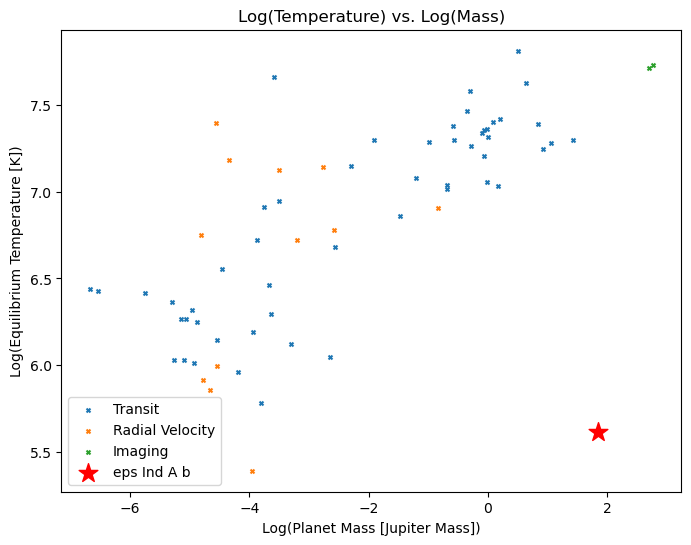

In [50]:
plt.figure(figsize=(8, 6))

df_transit = df_filtered[df_filtered[discover_col] == 'Transit'] 
plt.scatter(np.log(df_transit[mass_col]), np.log(df_transit[temp_col]), label='Transit', s=8, marker='x')

df_rv = df_filtered[df_filtered[discover_col] == 'Radial Velocity']
plt.scatter(np.log(df_rv[mass_col]), np.log(df_rv[temp_col]), label='Radial Velocity', s=8, marker='x')

df_imaging = df_filtered[df_filtered[discover_col] == 'Imaging']
plt.scatter(np.log(df_imaging[mass_col]), np.log(df_imaging[temp_col]), label='Imaging', s=8, marker='x')

planet_name = coldest_massive_planet['pl_name']

plt.scatter( np.log(coldest_massive_planet[mass_col]), np.log(coldest_massive_planet[temp_col]), color='red', marker='*', s=200, label=planet_name)

plt.title('Log(Temperature) vs. Log(Mass)')
plt.xlabel('Log(Planet Mass [Jupiter Mass])')
plt.ylabel('Log(Equilibrium Temperature [K])')
plt.legend()

plt.show()

In [ ]:
# A temperate super-Jupiter imaged with JWST in the mid-infrared
# Scientists used the JWST to look at a nearby, old star called Eps Ind A. Past data suggested a giant planet was there, and  JWST directly imaged a planet with simlar size, though different properties, than what was predicted
# Yes, our data is consistent with results (i.e. temperature of 275 K matches, and the planet appears to be incredibly massive but with low temperature
# It is extremely old, one of the first massive cold planets to be imaged, and has a stange atmospheric composition
# Yes, mass and equilibrium temperature are direct matches: 275K and 6.31 Jupiter Masses